In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 데이터 생성
- 남,여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [7]:
random.randint(140,195)

155

In [10]:
data = []
for i in range(50):
    # 여자 데이터 data 추가
    data.append([random.randint(40,70),random.randint(140,170)])
    # 남자 데이터 data 추가
    data.append([random.randint(60,95),random.randint(160,195)])
data

[[69, 150],
 [89, 163],
 [63, 164],
 [72, 193],
 [63, 170],
 [93, 193],
 [47, 168],
 [72, 193],
 [50, 144],
 [77, 186],
 [50, 164],
 [90, 162],
 [40, 156],
 [66, 165],
 [51, 162],
 [71, 195],
 [55, 154],
 [93, 176],
 [45, 140],
 [93, 183],
 [48, 166],
 [88, 164],
 [64, 165],
 [68, 174],
 [54, 147],
 [84, 182],
 [47, 145],
 [82, 188],
 [58, 165],
 [86, 160],
 [50, 159],
 [72, 183],
 [63, 165],
 [86, 161],
 [40, 168],
 [61, 178],
 [53, 159],
 [94, 174],
 [57, 152],
 [61, 175],
 [48, 157],
 [77, 182],
 [53, 166],
 [77, 178],
 [58, 169],
 [71, 167],
 [67, 147],
 [78, 164],
 [70, 152],
 [81, 172],
 [55, 156],
 [80, 181],
 [47, 151],
 [85, 160],
 [49, 164],
 [76, 175],
 [61, 149],
 [93, 160],
 [63, 140],
 [76, 190],
 [51, 143],
 [62, 164],
 [57, 170],
 [86, 160],
 [69, 166],
 [88, 190],
 [69, 144],
 [95, 193],
 [56, 144],
 [93, 191],
 [56, 169],
 [72, 164],
 [46, 143],
 [88, 169],
 [51, 150],
 [78, 188],
 [67, 167],
 [95, 195],
 [50, 149],
 [94, 171],
 [61, 167],
 [64, 175],
 [48, 148],
 [71

In [17]:
# 여자
# for female in data[::2]:
#     print(female, end='')
# print('여자 :',[female for female in data[::2]])
# print('남자 :',[male for male in data[1::2]])
print('='*50)
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축):', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축):', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [69, 63, 63, 47, 50, 50, 40, 51, 55, 45, 48, 64, 54, 47, 58, 50, 63, 40, 53, 57, 48, 53, 58, 67, 70, 55, 47, 49, 61, 63, 51, 57, 69, 69, 56, 56, 46, 51, 67, 50, 61, 48, 61, 45, 44, 58, 65, 40, 69, 67]
여자 키(y축): [150, 164, 170, 168, 144, 164, 156, 162, 154, 140, 166, 165, 147, 145, 165, 159, 165, 168, 159, 152, 157, 166, 169, 147, 152, 156, 151, 164, 149, 140, 143, 170, 166, 144, 144, 169, 143, 150, 167, 149, 167, 148, 143, 141, 163, 168, 151, 164, 141, 155]
남자 몸무게(x축) : [89, 72, 93, 72, 77, 90, 66, 71, 93, 93, 88, 68, 84, 82, 86, 72, 86, 61, 94, 61, 77, 77, 71, 78, 81, 80, 85, 76, 93, 76, 62, 86, 88, 95, 93, 72, 88, 78, 95, 94, 64, 71, 74, 69, 80, 87, 65, 93, 93, 61]
남자 키(y축): [163, 193, 193, 193, 186, 162, 165, 195, 176, 183, 164, 174, 182, 188, 160, 183, 161, 178, 174, 175, 182, 178, 167, 164, 172, 181, 160, 175, 160, 190, 164, 160, 190, 193, 191, 164, 169, 188, 195, 171, 175, 188, 180, 171, 183, 187, 167, 180, 187, 160]


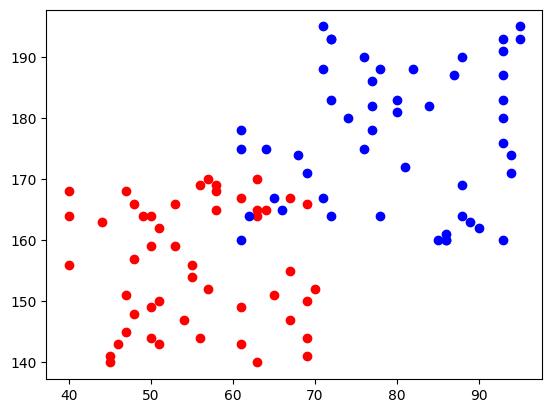

In [23]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'o', color="r")
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color="b")
plt.show()

# 2. 군집화 로직

In [24]:
# 초기 랜덤 지점 2개
random_points =[
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)]
]
random_points

[[40, 145], [63, 194]]

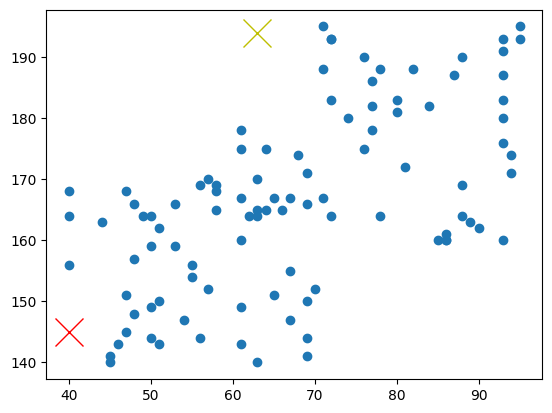

In [27]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0],
        random_points[0][1],'x', color='r', markersize=20) # 기준점 0(romdom_points[0])
plt.plot(random_points[1][0],
        random_points[1][1],'x', color='y', markersize=20) # 기준점 1(romdom_points[0])

In [28]:
# 두 점 거리를 return
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
dist([0,0],[3,4])

5.0

In [29]:
# random_point[0]에 가까운 그룹과 random_points[1]에 가까운 그룹을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(42, 58)

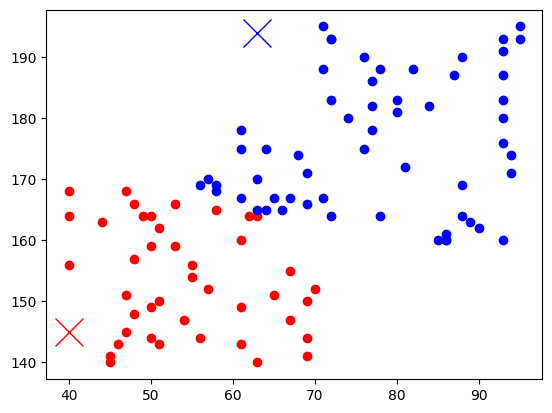

In [35]:
# group0과 group1, 기준점0, 기준점1
plt.plot([d[0] for d in group0],
        [d[1] for d in group0], 'o', color='r')
plt.plot(random_points[0][0],
        random_points[0][1],'x', color='r', markersize=20)

plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='b')
plt.plot(random_points[1][0],
        random_points[1][1],'x', color='b', markersize=20)

In [41]:
# 기준점 이동 : group0의 중심점(기준점0), group의 중심점(기준점1)
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX, group1_meanY]

random_points

[[54.166666666666664, 153.52380952380952],
 [77.46551724137932, 175.72413793103448]]

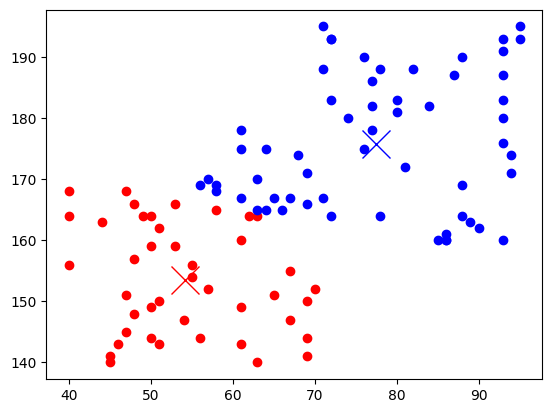

In [42]:
plt.plot([d[0] for d in group0],
        [d[1] for d in group0], 'o', color='r')
plt.plot(random_points[0][0],
        random_points[0][1],'x', color='r', markersize=20)

plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='b')
plt.plot(random_points[1][0],
        random_points[1][1],'x', color='b', markersize=20)


# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정
- 랜덤포인트 2개 출력과 시각화(x 마커)
- for문
    * 랜덤포인트 2지점 기준으로  group0과 group1 나눔
    * 랜덤포인트 출력
    * group0의 중간점과 group1의 중간점으로 랜덤포인트로 업데이트
    * 랜덤 포인트 출력과 시각화

초기 기준점 : [[64, 149], [86, 190]]
1 번째 point : [[59.0625, 158.015625], [83.0, 181.30555555555554]]
2 번째 point : [[57.0, 158.1], [83.7, 178.85]]
3 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
4 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
5 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
6 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
7 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
8 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]
9 번째 point : [[56.79661016949152, 157.88135593220338], [83.34146341463415, 178.65853658536585]]


(140.0, 195.0)

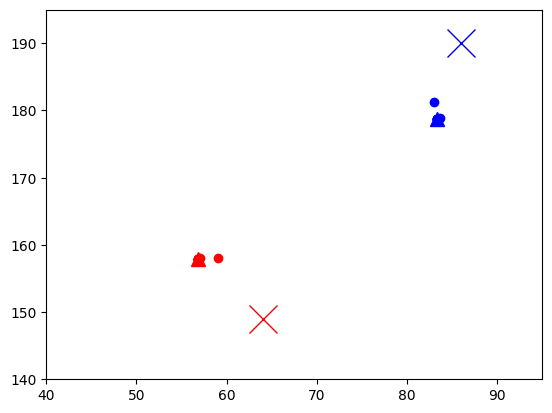

In [52]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)]
]
print('초기 기준점 :', points)
plt.plot(points[0][0],points[0][1],'x', color='r', markersize=20)
plt.plot(points[1][0],points[1][1],'x', color='b', markersize=20)
for i in  range(1,10):
    # 랜덤포인트 2지점 기준으로  group0과 group1 나눔
    group0 = []
    group1 = []
    for d in data:
        if dist(d, points[0]) < dist(d,points[1]):
            group0.append(d)
        else:
            group1.append(d)
    
    # group0의 중간점과 group1의 중간점으로 랜덤포인트로 업데이트
    group0_mean_X = np.mean([d[0] for d in group0])
    group0_mean_Y= np.mean([d[1] for d in group0])
    group1_mean_X = np.mean([d[0] for d in group1])
    group1_mean_Y= np.mean([d[1] for d in group1])
    points=[[group0_mean_X,group0_mean_Y],[group1_mean_X,group1_mean_Y]]
    
    # 포인트 출력
    print(i, "번째 point :", points)
    plt.plot(points[0][0],points[0][1],'o', color='r')
    plt.plot(points[1][0],points[1][1],'o', color='b')

# 최종포인트
plt.plot(points[0][0],points[0][1],'^', color='r', markersize=10)
plt.plot(points[1][0],points[1][1],'^', color='b', markersize=10) 

plt.xlim([40,95])
plt.ylim([140,195])

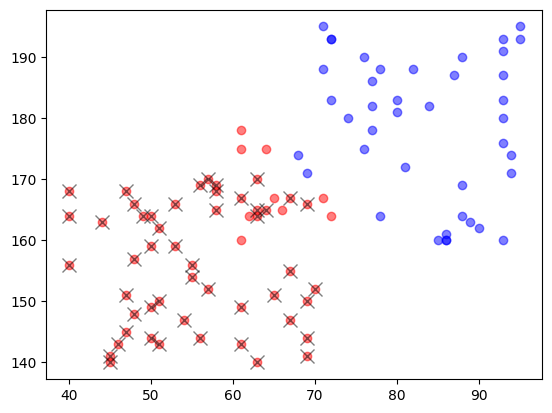

In [61]:
plt.plot([d[0] for d in group0],
        [d[1] for d in group0], 'o', color='r', alpha=0.5)
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='b', alpha=0.5)
plt.plot([d[0] for d in data[::2]],
        [d[1] for d in data[::2]], 'x', color='k', alpha=0.5, markersize=10)

# 4. API(sklearn)를 이용한 군집화
- sklearn :머신러닝 패키지
    * 예측모델 : 분류, 회귀, 군집분석 - fit(학습), predict(예측)
    * 변환모델 : 전처리시 사용 ex. 인코딩, 스케일조정 - fit(학습), trnasform(변환함수), fit_transform(학->변)

In [ ]:
# 군집분석 라이브러리가 경고 메세지(joblib충돌) 출력할 경우 - 주의)사용시 느려짐
# import os
# os.environ['OMP_NUM_THREADS']='1'

In [66]:
from sklearn.cluster import KMeans
data=np.array(data)
model = KMeans(n_clusters=2,  # 2개 그룹으로 군집
               init='random', # 초기 기준점을 random
               n_init=10,     # 실행횟수(10회)
               random_state=7,# random 결과를 일관적으로 맞추기 위한 seed 
              )
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [67]:
# 기준점(중심점)
model.cluster_centers_

array([[ 82.60465116, 178.30232558],
       [ 56.42105263, 157.42105263]])

In [68]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1])

In [70]:
group0 = data[model.labels_ == 0]
group1 = data[model.labels_ == 1]